# MCDI505 — Análisis de Series de Tiempo
## Sumativa 1 — Plantilla de apoyo para análisis exploratorio

**Estudiante:** [COMPLETAR]  
**Fecha:** [COMPLETAR]  
**Dataset:** `consumo_electrico_litoral.csv`


## 1. Introducción y objetivo

Este notebook organiza el análisis exigido por la rúbrica: (1) exploración y visualización, (2) descomposición e identificación de componentes, (3) ACF y PACF, y (4) interpretación técnica integrada.

El objetivo de este análisis es estudiar el comportamiento temporal del consumo eléctrico del litoral, con el propósito de identificar los principales patrones presentes en la serie, tales como tendencia, estacionalidad, posibles fluctuaciones cíclicas y variaciones no explicadas. Para ello, se realizará inicialmente una exploración gráfica y descriptiva de los datos y posteriormente se aplicará una descomposición de la serie junto con el análisis de las funciones de autocorrelación (ACF) y autocorrelación parcial (PACF). Esto permitirá comprender cómo evoluciona el consumo a través del tiempo y determinar si existe dependencia entre las observaciones de distintos períodos.
El dataset contiene registros mensuales de consumo eléctrico correspondientes al período comprendido entre enero de 2015 y diciembre de 2024, lo que representa 120 períodos mensuales. La variable temporal corresponde a la fecha de cada observación y la variable de interés es consumo_gwh, que representa el consumo eléctrico medido en gigawatt-hora (GWh). Debido a que la información presenta una frecuencia mensual, resulta especialmente relevante analizar la existencia de patrones que puedan repetirse cada 12 meses, además de estudiar la evolución de largo plazo de la serie y las posibles dependencias entre meses consecutivos..

## 2. Configuración del entorno y carga reproducible

La celda siguiente intenta encontrar el CSV directamente o extraerlo desde `f1_s01_dataset.zip`. Esto permite ejecutar el notebook desde una carpeta limpia, siempre que el dataset o el ZIP estén junto al notebook.

In [1]:
from pathlib import Path
import zipfile
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import acf, pacf

warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (12, 4.5)
plt.rcParams["axes.grid"] = True

# Buscar el CSV en ubicaciones habituales.
candidatos = [
    Path("consumo_electrico_litoral.csv"),
    Path("f1_dataset/consumo_electrico_litoral.csv"),
]

csv_path = next((p for p in candidatos if p.exists()), None)

if csv_path is None:
    zip_path = Path("f1_s01_dataset.zip")
    if not zip_path.exists():
        raise FileNotFoundError(
            "No se encontró consumo_electrico_litoral.csv ni f1_s01_dataset.zip. "
            "Ubique uno de ellos en la misma carpeta del notebook."
        )
    destino = Path("f1_dataset")
    destino.mkdir(exist_ok=True)
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(destino)
    csv_path = destino / "consumo_electrico_litoral.csv"

print(f"Archivo utilizado: {csv_path.resolve()}")

Archivo utilizado: /mnt/data/nb_run/consumo_electrico_litoral.csv


In [2]:
# Carga y normalización del índice temporal.
df = pd.read_csv(csv_path, parse_dates=["fecha"])
df = df.sort_values("fecha").set_index("fecha")
df.index = pd.DatetimeIndex(df.index)
df = df.asfreq("MS")

print(f"Dimensiones: {df.shape}")
display(df.head())
display(df.tail())

Dimensiones: (120, 4)


,consumo_gwh,clientes_comerciales,temperatura_media_c,dias_habiles
fecha,,,,
2015-01-01,108.32,41827,19.6,22
2015-02-01,94.71,41918,18.7,20
2015-03-01,89.52,42045,16.5,22
2015-04-01,82.24,42129,13.3,22
2015-05-01,82.60,42242,12.0,21


,consumo_gwh,clientes_comerciales,temperatura_media_c,dias_habiles
fecha,,,,
2024-08-01,115.22,56356,12.6,22
2024-09-01,110.39,56523,14.1,21
2024-10-01,111.00,56652,17.0,23
2024-11-01,117.70,56774,19.6,21
2024-12-01,137.47,56885,20.1,22


## 3. Contexto y auditoría de calidad de datos

Antes de analizar una serie temporal se verifica la integridad del índice, frecuencia, duplicados, valores faltantes y estadística descriptiva. Esta etapa evita interpretar artefactos producidos por problemas de calidad.

In [3]:
print("Periodo:", df.index.min().date(), "a", df.index.max().date())
print("Frecuencia inferida:", pd.infer_freq(df.index))
print("Observaciones:", len(df))
print("Fechas duplicadas:", df.index.duplicated().sum())
print("Valores faltantes por variable:")
display(df.isna().sum().to_frame("n_faltantes"))

display(df.describe().T)

faltantes = df.index[df["consumo_gwh"].isna()]
print("Meses con consumo faltante:", [d.strftime("%Y-%m") for d in faltantes])

Periodo: 2015-01-01 a 2024-12-01
Frecuencia inferida: MS
Observaciones: 120
Fechas duplicadas: 0
Valores faltantes por variable:


,n_faltantes
consumo_gwh,3
clientes_comerciales,0
temperatura_media_c,0
dias_habiles,0


,count,mean,std,min,25%,50%,75%,max
consumo_gwh,117.0,104.612137,13.645166,73.19,95.74,102.94,114.88,145.82
clientes_comerciales,120.0,49389.591667,4581.499820,41827.00,45269.50,49761.50,53472.25,56885.00
temperatura_media_c,120.0,15.700000,3.186236,10.50,12.60,15.35,18.40,21.70
dias_habiles,120.0,21.741667,0.948203,20.00,21.00,22.00,22.00,23.00


Meses con consumo faltante: ['2016-08', '2019-02', '2022-06']


### 3.1 Decisión de tratamiento de faltantes

La serie contiene observaciones faltantes y debe definirse una estrategia antes de la descomposición y ACF/PACF. La siguiente celda compara alternativas simples sin decidir por el estudiante.

Para tratar los valores faltantes se utilizará interpolación temporal lineal, debido a que los datos ausentes corresponden a huecos aislados dentro de una serie con frecuencia mensual. Este método estima cada valor faltante utilizando la evolución de las observaciones temporalmente cercanas, permitiendo mantener la continuidad y la frecuencia regular de la serie. Esto es importante para aplicar posteriormente la descomposición STL y analizar correctamente las funciones ACF y PACF, ya que eliminar los meses con datos faltantes alteraría la secuencia temporal y la interpretación de los rezagos.
Sin embargo, la interpolación introduce valores estimados y no observados, por lo que puede suavizar artificialmente la variabilidad de la serie y modificar ligeramente las autocorrelaciones o los residuos. Este riesgo se considera acotado en este caso debido a que los faltantes son pocos y aislados. Por esta razón, los valores imputados se mantienen identificados y su tratamiento debe considerarse al interpretar los resultados posteriores..

In [4]:
s = df["consumo_gwh"].copy()
comparacion = pd.DataFrame({
    "original": s,
    "lineal": s.interpolate("linear"),
    "temporal": s.interpolate("time"),
})

# Alternativa estacional: mismo mes del año anterior/siguiente cuando exista.
est = s.copy()
for fecha in faltantes:
    vals = []
    for delta in (-12, 12):
        pos = df.index.get_loc(fecha) + delta
        if 0 <= pos < len(df):
            v = s.iloc[pos]
            if pd.notna(v): vals.append(v)
    if vals:
        est.loc[fecha] = np.mean(vals)
comparacion["estacional_vecinos"] = est

display(comparacion.loc[faltantes])

,original,lineal,temporal,estacional_vecinos
fecha,,,,
2016-08-01,NaN,95.860,95.860000,93.850
2019-02-01,NaN,116.925,116.343559,115.725
2022-06-01,NaN,101.395,101.430328,103.095


In [5]:
# IMPORTANTE: cambie esta línea si su decisión metodológica es otra.
y = s.interpolate("time")
y.name = "consumo_gwh"

assert y.notna().all(), "La serie analítica aún contiene faltantes."
print("Serie analítica preparada:", len(y), "observaciones mensuales")

Serie analítica preparada: 120 observaciones mensuales


## 4. Criterio 1 — Exploración y visualización de la serie

La rúbrica exige gráficos completos y una descripción precisa de tendencia, estacionalidad, ciclos, cambios de nivel y/o varianza. Se presentan varias vistas complementarias para que la interpretación no dependa de un único gráfico.

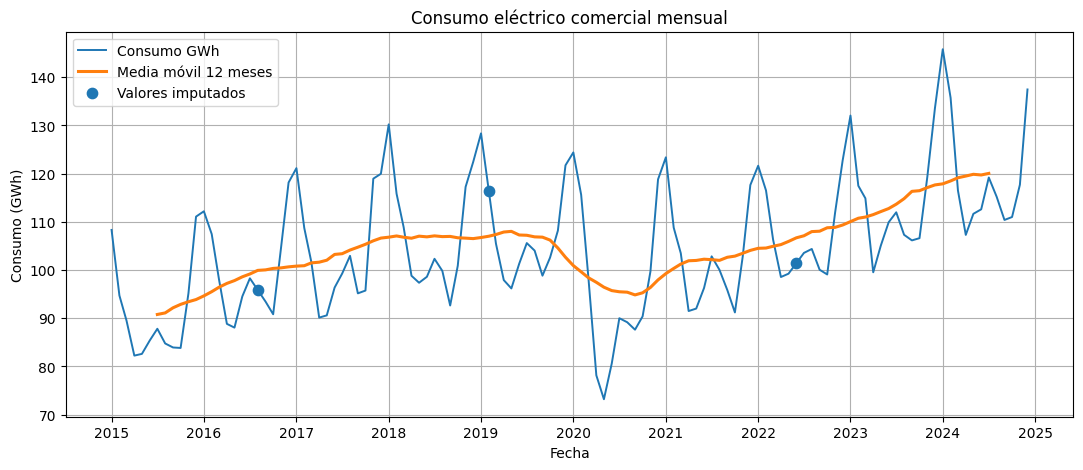

In [6]:
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(y.index, y, lw=1.4, label="Consumo GWh")
ax.plot(y.rolling(12, center=True).mean(), lw=2.2, label="Media móvil 12 meses")
ax.scatter(faltantes, y.loc[faltantes], s=55, zorder=4, label="Valores imputados")
ax.set(title="Consumo eléctrico comercial mensual", xlabel="Fecha", ylabel="Consumo (GWh)")
ax.legend()
plt.show()

,mean,std,median
mes,,,
1,124.76,10.50,123.90
2,113.72,10.39,115.72
3,104.29,8.10,104.48
4,93.29,8.81,94.70
5,93.59,11.01,94.09
6,97.70,9.76,97.48
7,102.09,9.30,102.58
8,100.35,8.78,101.48
9,96.41,7.94,95.50


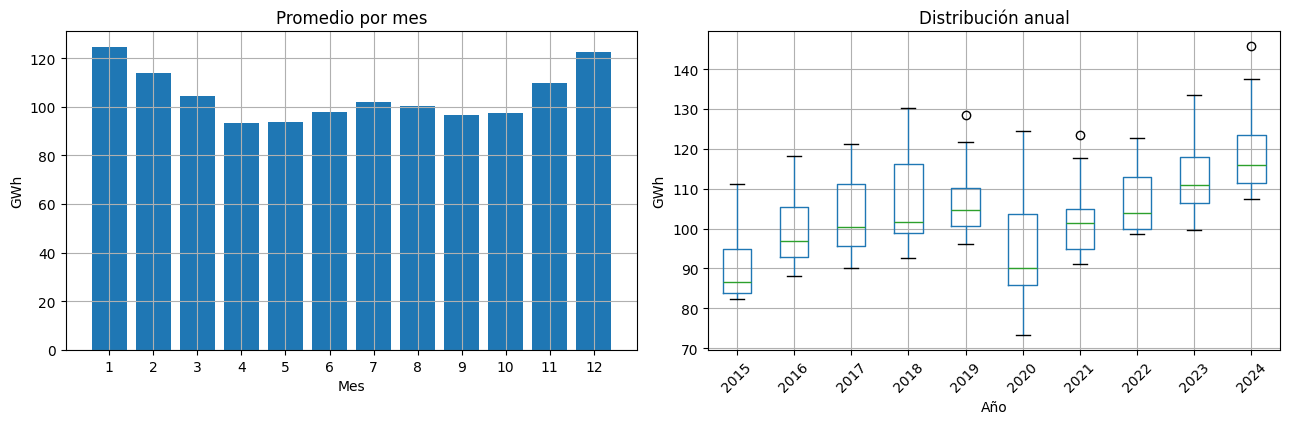

In [7]:
# Perfil estacional mensual y dispersión anual.
perfil_mes = y.groupby(y.index.month).agg(["mean", "std", "median"])
perfil_mes.index.name = "mes"
display(perfil_mes.round(2))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].bar(perfil_mes.index, perfil_mes["mean"])
axes[0].set(title="Promedio por mes", xlabel="Mes", ylabel="GWh")
axes[0].set_xticks(range(1,13))

year_df = pd.DataFrame({"año": y.index.year, "consumo": y.values})
year_df.boxplot(column="consumo", by="año", ax=axes[1], rot=45)
axes[1].set(title="Distribución anual", xlabel="Año", ylabel="GWh")
plt.suptitle("")
plt.tight_layout()
plt.show()

Correlación media móvil vs desviación móvil: -0.078


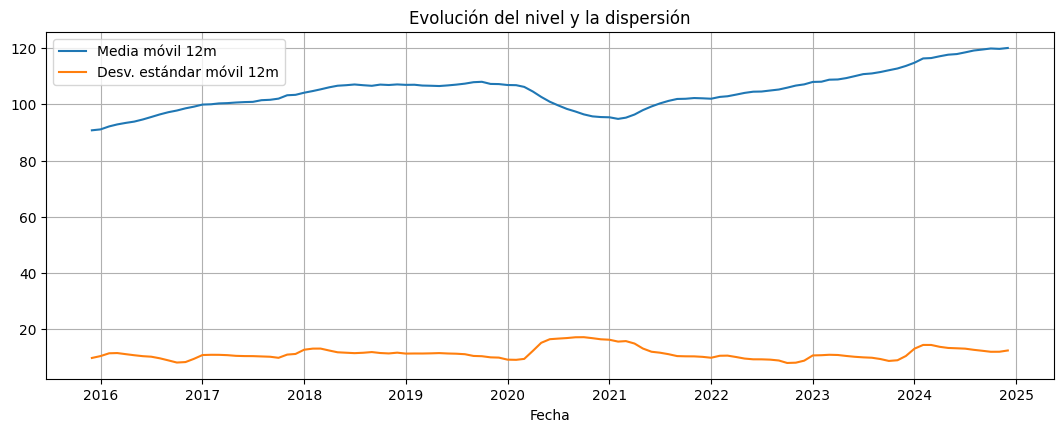

In [8]:
# Diagnóstico de relación nivel-varianza para apoyar la elección aditiva/multiplicativa.
roll_mean = y.rolling(12).mean()
roll_std = y.rolling(12).std()
valid = roll_mean.notna() & roll_std.notna()
corr_nivel_disp = roll_mean[valid].corr(roll_std[valid])
print(f"Correlación media móvil vs desviación móvil: {corr_nivel_disp:.3f}")

fig, ax = plt.subplots(figsize=(13, 4.5))
ax.plot(roll_mean, label="Media móvil 12m")
ax.plot(roll_std, label="Desv. estándar móvil 12m")
ax.set(title="Evolución del nivel y la dispersión", xlabel="Fecha")
ax.legend()
plt.show()

### 4.1 Interpretación exploratoria

La exploración gráfica muestra que la serie de consumo eléctrico presenta una tendencia general creciente durante el período 2015–2024, aunque este crecimiento no es uniforme. El promedio anual aumenta desde aproximadamente 90,78 GWh en 2015 hasta 120,05 GWh en 2024, lo que evidencia un incremento del nivel de consumo en el largo plazo. Dentro de esta trayectoria se observa una alteración importante alrededor de 2020, donde el consumo disminuye respecto de la evolución previa, seguida posteriormente por una recuperación y continuación de la tendencia creciente.
También se identifica un patrón estacional de periodicidad anual, coherente con la frecuencia mensual de los datos. Al comparar los meses entre los distintos años, los mayores niveles promedio se concentran especialmente en enero (≈124,76 GWh) y diciembre (≈122,36 GWh), mientras que abril y mayo presentan valores promedio cercanos a 93 GWh. Esta repetición de máximos y mínimos en meses similares sugiere un patrón que se reproduce aproximadamente cada 12 meses.
Respecto de los ciclos o perturbaciones, el comportamiento alrededor de 2020–2021 destaca como una fluctuación de mayor duración que las oscilaciones estacionales habituales. Sin embargo, en esta etapa exploratoria no corresponde afirmar que se trate de un ciclo periódico; es más adecuado considerarlo como una perturbación o cambio temporal de nivel, cuya naturaleza deberá contrastarse posteriormente con la descomposición de la serie. Después de este período se observa una recuperación del consumo hacia niveles superiores.
En cuanto a la varianza, visualmente las oscilaciones no parecen aumentar de manera proporcional al crecimiento del nivel de la serie. Esto también es consistente con el análisis de nivel y dispersión realizado posteriormente, donde la relación resulta débil. Por lo tanto, en esta etapa no se aprecia evidencia clara de una varianza que aumente sistemáticamente junto con el nivel del consumo. Sí se observan cambios temporales de nivel, especialmente en torno a 2020 y durante la recuperación posterior.
Finalmente, la serie presenta tres observaciones faltantes, correspondientes a agosto de 2016, febrero de 2019 y junio de 2022, las cuales fueron tratadas mediante interpolación temporal para mantener la continuidad mensual. Esta decisión permite conservar los 120 períodos necesarios para los análisis posteriores, pero debe considerarse que los valores interpolados son estimaciones y pueden producir un leve suavizamiento local de la serie. Debido a que los faltantes son aislados y representan solo 3 de 120 observaciones (2,5 %), su efecto esperado sobre la interpretación global es acotado, aunque debe tenerse presente especialmente al analizar variabilidad, residuos y autocorrelaciones.

## 5. Criterio 2 — Descomposición e identificación de componentes

Se utiliza **STL** con periodo 12, adecuado para una serie mensual con estacionalidad anual y robusto para explorar tendencia, componente estacional y residuo. La elección definitiva y su justificación deben relacionarse con la evidencia observada en la sección anterior.

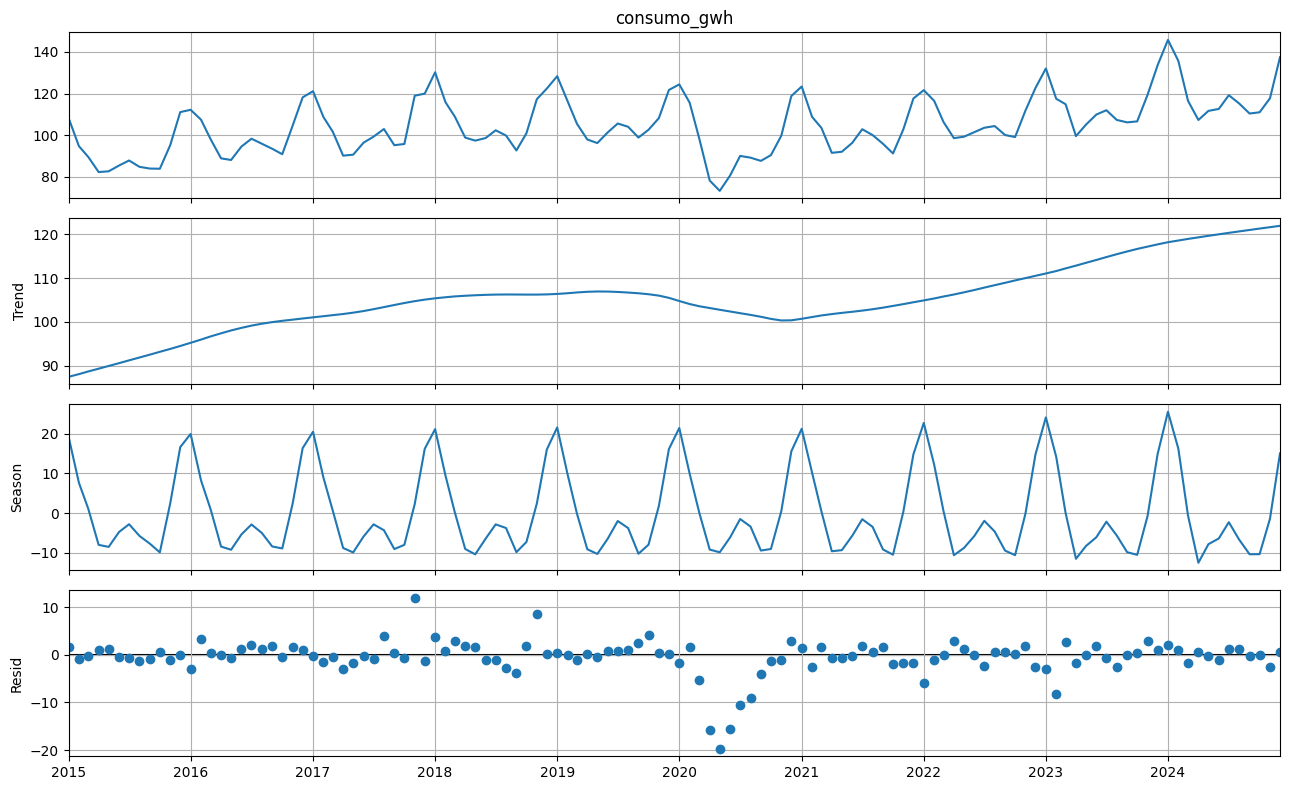

In [9]:
# STL sobre nivel. Si su decisión justifica transformación logarítmica,
# puede reemplazar y por np.log(y) y explicar cómo interpretar los componentes.
stl = STL(y, period=12, robust=True)
res = stl.fit()

fig = res.plot()
fig.set_size_inches(13, 8)
plt.tight_layout()
plt.show()

In [10]:
componentes = pd.DataFrame({
    "observada": y,
    "tendencia": res.trend,
    "estacional": res.seasonal,
    "residuo": res.resid,
})

display(componentes.describe().T.round(3))

# Fuerza descriptiva de tendencia y estacionalidad (Hyndman-style, acotada 0..1).
var_r = np.var(res.resid, ddof=1)
var_rt = np.var(res.resid + res.trend, ddof=1)
var_rs = np.var(res.resid + res.seasonal, ddof=1)
f_tend = max(0, 1 - var_r / var_rt) if var_rt > 0 else np.nan
f_est = max(0, 1 - var_r / var_rs) if var_rs > 0 else np.nan
print(f"Fuerza descriptiva de tendencia: {f_tend:.3f}")
print(f"Fuerza descriptiva de estacionalidad: {f_est:.3f}")

,count,mean,std,min,25%,50%,75%,max
observada,120.0,104.610,13.542,73.190,95.815,102.890,114.965,145.820
tendencia,120.0,105.165,7.836,87.436,101.135,104.977,107.399,121.918
estacional,120.0,-0.071,10.296,-12.475,-8.552,-3.107,3.749,25.492
residuo,120.0,-0.484,3.792,-19.725,-1.173,-0.031,1.245,11.974


Fuerza descriptiva de tendencia: 0.818
Fuerza descriptiva de estacionalidad: 0.885


### 5.1 Interpretación de la descomposición

Para descomponer la serie se utilizó el método STL (Seasonal-Trend decomposition using LOESS) con un esquema aditivo y periodicidad de 12 meses. Esta elección se justifica porque en el gráfico original la amplitud de las fluctuaciones estacionales se mantiene relativamente estable a medida que aumenta el nivel del consumo. Además, la relación calculada entre el nivel y la dispersión móvil presenta una correlación cercana a −0,078, valor próximo a cero que no entrega evidencia de que la variabilidad aumente proporcionalmente con el nivel de la serie. Por esta razón, resulta razonable representar el consumo mediante una estructura aditiva, donde la serie observada se interpreta como la suma de tendencia + estacionalidad + residuo. STL resulta apropiado además porque permite estimar de manera flexible una tendencia suavizada y un componente estacional para una serie mensual.
La tendencia obtenida mediante STL confirma una evolución creciente de largo plazo, aunque no completamente uniforme. Durante los primeros años se aprecia un aumento progresivo del nivel de consumo, seguido por una alteración importante alrededor de 2020–2021, donde la tendencia se reduce respecto de la trayectoria anterior. Posteriormente se observa una recuperación y un nuevo crecimiento, alcanzando hacia el final de la serie niveles superiores a los registrados al comienzo del período. Esta evolución es consistente con el análisis exploratorio, donde el promedio anual pasa de aproximadamente 90,78 GWh en 2015 a 120,05 GWh en 2024.
El componente de estacionalidad muestra un patrón recurrente dentro de cada año. Debido a que la serie tiene frecuencia mensual, se utilizó period=12, por lo que una repetición cada 12 observaciones corresponde a una periodicidad anual. El componente estacional es consistente con el perfil mensual observado previamente, en el cual enero y diciembre presentan consumos promedio más elevados, mientras que abril y mayo presentan niveles promedio inferiores. La fuerza de estacionalidad obtenida es aproximadamente 0,885, lo que indica que la estacionalidad constituye una parte importante y sistemática de la estructura temporal de la serie. Asimismo, la fuerza de tendencia es aproximadamente 0,818, confirmando que tanto la evolución de largo plazo como el patrón anual tienen una presencia relevante.
Respecto del ciclo, en este análisis debe distinguirse de la estacionalidad. La estacionalidad corresponde a movimientos regulares que se repiten con una periodicidad conocida, en este caso aproximadamente cada 12 meses, mientras que un ciclo representa fluctuaciones de mediano o largo plazo cuya duración no necesariamente es fija. STL no entrega explícitamente un componente cíclico separado, sino solamente tendencia, estacionalidad y residuo. En la serie se observa una caída y posterior recuperación alrededor de 2020–2021, que podría considerarse una fluctuación de mediano plazo incorporada principalmente en la tendencia suavizada. Sin embargo, con los datos disponibles no existe evidencia suficiente para afirmar que corresponda a un ciclo periódico recurrente, por lo que resulta más prudente interpretarla como una perturbación temporal o cambio de nivel.
Finalmente, el componente de error o residuo representa la variación que permanece después de retirar la tendencia y la estacionalidad estimadas por STL. La desviación estándar de los residuos es aproximadamente 3,79 GWh, considerablemente menor que la variabilidad total de la serie, lo que indica que la descomposición captura una parte importante de su estructura sistemática. No obstante, aparecen residuos de mayor magnitud especialmente durante abril–junio de 2020, señalando observaciones que la tendencia y la estacionalidad regular no explican completamente. Visualmente, los residuos se concentran principalmente alrededor de cero y no muestran una tendencia tan evidente como la serie original. Sin embargo, determinar si todavía permanece dependencia temporal requiere complementar esta inspección con el análisis posterior de ACF y PACF, por lo que no corresponde concluir únicamente a partir del gráfico residual que el error sea completamente aleatorio.

## 6. Criterio 3 — Análisis de autocorrelación (ACF y PACF)

ACF mide correlación entre la serie y sus rezagos; PACF mide la correlación parcial de un rezago controlando los rezagos intermedios. Para una serie mensual se inspeccionan hasta 48 rezagos (4 años), prestando especial atención a 12, 24, 36 y 48.

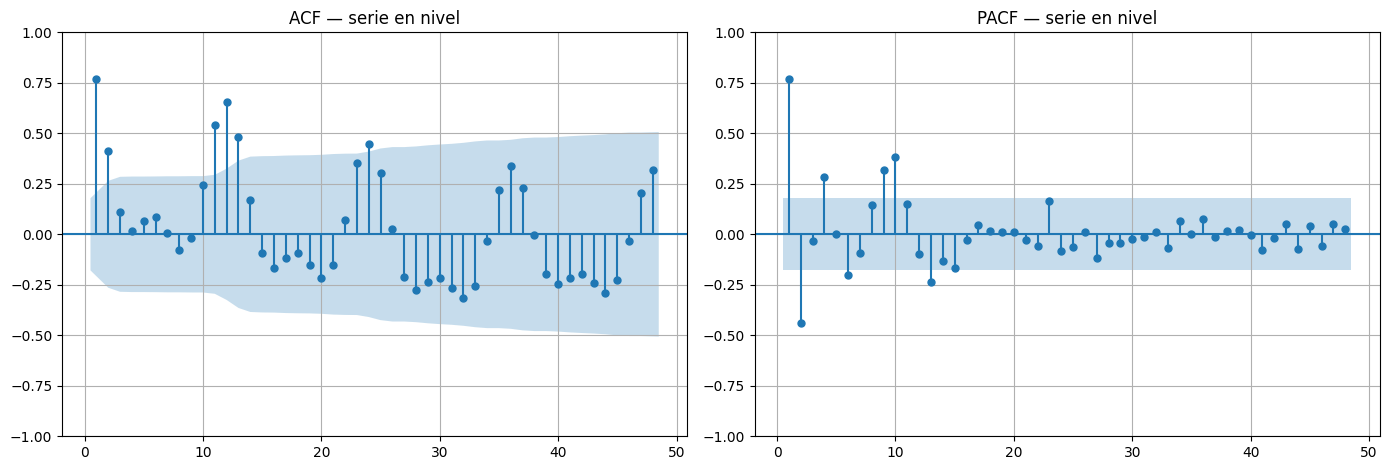

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
plot_acf(y, lags=48, ax=axes[0], alpha=0.05, zero=False)
plot_pacf(y, lags=48, ax=axes[1], alpha=0.05, zero=False, method="ywm")
axes[0].set_title("ACF — serie en nivel")
axes[1].set_title("PACF — serie en nivel")
plt.tight_layout()
plt.show()

In [12]:
# Tabla reproducible de ACF/PACF y umbral aproximado 95%: ±1.96/sqrt(N).
NLAGS = 48
acf_vals = acf(y, nlags=NLAGS, fft=True)
pacf_vals = pacf(y, nlags=NLAGS, method="ywm")
umbral = 1.96 / np.sqrt(len(y))

tabla_corr = pd.DataFrame({
    "lag": np.arange(1, NLAGS + 1),
    "ACF": acf_vals[1:],
    "PACF": pacf_vals[1:],
})
tabla_corr["ACF_signif_aprox"] = tabla_corr["ACF"].abs() > umbral
tabla_corr["PACF_signif_aprox"] = tabla_corr["PACF"].abs() > umbral

print(f"Umbral aproximado 95%: ±{umbral:.3f}")
display(tabla_corr.round(3))
print("Rezagos ACF significativos (aprox.):", tabla_corr.loc[tabla_corr.ACF_signif_aprox, "lag"].tolist())
print("Rezagos PACF significativos (aprox.):", tabla_corr.loc[tabla_corr.PACF_signif_aprox, "lag"].tolist())

Umbral aproximado 95%: ±0.179


,lag,ACF,PACF,ACF_signif_aprox,PACF_signif_aprox
0,1,0.771,0.771,True,True
1,2,0.415,-0.441,True,True
2,3,0.109,-0.035,False,False
3,4,0.018,0.282,False,True
4,5,0.064,0.004,False,False
5,6,0.085,-0.204,False,True
6,7,0.008,-0.090,False,False
7,8,-0.080,0.147,False,False
8,9,-0.019,0.320,False,True
9,10,0.244,0.383,True,True


Rezagos ACF significativos (aprox.): [1, 2, 10, 11, 12, 13, 20, 23, 24, 25, 27, 28, 29, 30, 31, 32, 33, 35, 36, 37, 39, 40, 41, 42, 43, 44, 45, 47, 48]
Rezagos PACF significativos (aprox.): [1, 2, 4, 6, 9, 10, 13]


### 6.1 Interpretación ACF/PACF

La ACF de la serie original presenta un decaimiento gradual y no un corte rápido, comenzando con una autocorrelación alta en el primer rezago, ACF(1) ≈ 0,771, y manteniendo correlaciones relevantes en rezagos posteriores. Este comportamiento indica una fuerte persistencia temporal, es decir, el consumo de un mes está relacionado con observaciones anteriores y los efectos no desaparecen inmediatamente. El decaimiento relativamente lento también sugiere que la serie original podría no ser estacionaria, lo que resulta coherente con la tendencia identificada previamente. Sin embargo, la estacionariedad no debe concluirse únicamente mediante el gráfico ACF, por lo que antes de ajustar un modelo sería conveniente evaluarla formalmente y comparar la serie original con versiones diferenciadas.
Además, la ACF presenta valores relevantes en los múltiplos de 12, destacando aproximadamente ACF(12)=0,654, ACF(24)=0,448, ACF(36)=0,336 y ACF(48)=0,317. Dado que los datos tienen frecuencia mensual, estos rezagos representan aproximadamente uno, dos, tres y cuatro años respectivamente. La persistencia de autocorrelaciones positivas en dichos múltiplos constituye evidencia de una estructura estacional anual, consistente con el patrón de 12 meses observado en los gráficos exploratorios y con el componente estacional identificado mediante STL.
En la PACF destacan como aproximadamente significativos los rezagos 1, 2, 4, 6, 9, 10 y 13, considerando como referencia el intervalo aproximado del 95 % de ±1,96/√120 ≈ ±0,179. El rezago 1 es especialmente relevante, ya que indica una dependencia directa importante entre el consumo de un mes y el del mes inmediatamente anterior, después de controlar el efecto de los rezagos intermedios. Los demás rezagos significativos sugieren que la dependencia temporal no queda explicada únicamente por el mes inmediatamente anterior, sino que existe una estructura más compleja. Por otra parte, que PACF(12) no destaque individualmente no contradice la existencia de estacionalidad anual, ya que PACF mide dependencia directa condicionada por los rezagos intermedios, mientras que la estacionalidad está respaldada conjuntamente por la ACF en 12, 24, 36 y 48 meses, el perfil mensual y la descomposición STL.
En conjunto, los resultados de ACF y PACF son coherentes con la exploración y la descomposición. La persistencia observada en los primeros rezagos de la ACF es compatible con la tendencia de largo plazo identificada en la serie, mientras que las autocorrelaciones elevadas en múltiplos de 12 coinciden con la estacionalidad anual detectada visualmente y mediante STL. Por lo tanto, las distintas herramientas entregan evidencia consistente de que la serie contiene tanto dependencia de corto plazo como tendencia y estructura estacional anual.
Antes de ajustar un modelo ARIMA/SARIMA evaluaría primero una diferenciación regular de orden 1, diff(1), para reducir la tendencia y persistencia de largo plazo, y una diferenciación estacional de orden 1 con período 12, diff(12), para reducir la dependencia anual. También evaluaría la combinación diff(1).diff(12), equivalente conceptualmente a considerar d=1, D=1 y s=12, comparando posteriormente sus ACF y PACF con las de la serie original. La elección no debería realizarse automáticamente: se debe seleccionar la transformación mínima que permita obtener un comportamiento suficientemente estacionario sin provocar sobrediferenciación. En una etapa posterior, esta evidencia permitiría evaluar modelos de la familia SARIMA(p,d,q)(P,D,Q,12), cuya configuración definitiva debería compararse mediante criterios estadísticos, validación temporal y diagnóstico de residuos.

**Nota:** el umbral `±1.96/sqrt(N)` es una referencia aproximada. La interpretación principal debe considerar las bandas de confianza mostradas por `statsmodels` y el patrón conjunto, no solo una lista mecánica de rezagos.

## 7. Análisis complementario: ACF/PACF de una serie transformada

Esta sección es diagnóstica. Una diferencia regular puede reducir tendencia y una diferencia estacional de 12 meses puede reducir estacionalidad. Comparar los correlogramas ayuda a entender qué estructura proviene de esos componentes.

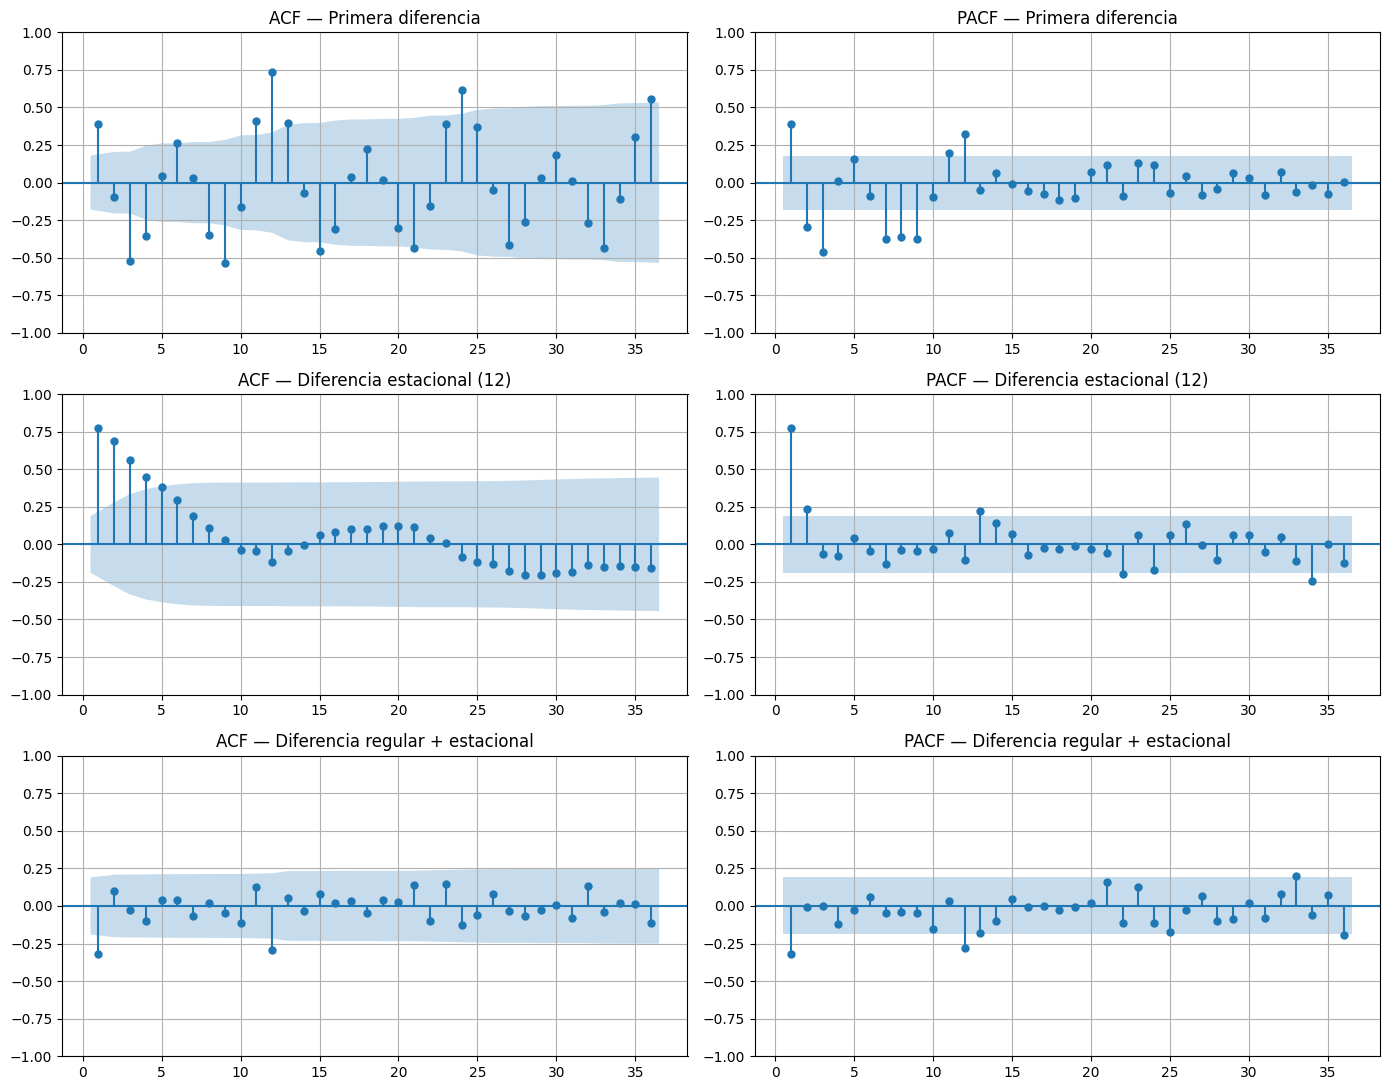

In [13]:
y_diff = y.diff().dropna()
y_sdiff = y.diff(12).dropna()
y_both = y.diff().diff(12).dropna()

fig, axes = plt.subplots(3, 2, figsize=(14, 11))
for row, (serie, nombre) in enumerate([
    (y_diff, "Primera diferencia"),
    (y_sdiff, "Diferencia estacional (12)"),
    (y_both, "Diferencia regular + estacional"),
]):
    max_lags = min(36, len(serie)//2 - 1)
    plot_acf(serie, lags=max_lags, ax=axes[row,0], zero=False)
    plot_pacf(serie, lags=max_lags, ax=axes[row,1], zero=False, method="ywm")
    axes[row,0].set_title(f"ACF — {nombre}")
    axes[row,1].set_title(f"PACF — {nombre}")
plt.tight_layout()
plt.show()

### 7.1 Lectura comparativa

Al comparar la serie original con las versiones diferenciadas, se observa que la diferenciación regular de primer orden, diff(1), reduce principalmente la tendencia y la fuerte persistencia presente en la serie original. Esto ocurre porque, en lugar de trabajar con el nivel de consumo de cada mes, se analiza el cambio respecto del mes inmediatamente anterior. Como consecuencia, la ACF deja de presentar el decaimiento lento característico de la serie en niveles. Sin embargo, todavía puede permanecer dependencia asociada a la periodicidad anual, por lo que esta transformación por sí sola no necesariamente elimina toda la estructura estacional.
La diferenciación estacional, diff(12), actúa de manera diferente, ya que compara cada observación con la correspondiente a doce meses antes. Debido a que la serie presenta una estacionalidad anual clara, esta transformación reduce específicamente el patrón repetitivo asociado a los rezagos 12, 24, 36 y 48, que en la serie original presentaban autocorrelaciones relevantes. Por esta razón, diff(12) resulta especialmente útil para controlar la dependencia estacional anual, aunque puede permanecer estructura temporal de corto plazo o una tendencia residual.
Al aplicar conjuntamente la diferenciación regular y la estacional, diff(1).diff(12), se busca remover simultáneamente la tendencia/persistencia de largo plazo y el patrón estacional anual. Comparativamente, esta transformación produce una serie más centrada alrededor de un nivel aproximadamente estable y con una ACF que pierde gran parte de la persistencia observada en la serie original. Por lo tanto, de las alternativas evaluadas, la diferenciación combinada parece ser una candidata razonable para obtener una serie más cercana a la estacionariedad.
Sin embargo, esta comparación debe considerarse como una hipótesis para el modelamiento posterior y no como una selección definitiva del modelo. A partir de los resultados, sería razonable evaluar posteriormente modelos SARIMA con periodicidad estacional s=12, considerando como hipótesis inicial una diferenciación regular d=1 y una diferenciación estacional D=1. Los órdenes autorregresivos y de media móvil, (p,q) y (P,Q), no deberían definirse exclusivamente mediante la inspección visual de ACF y PACF. La selección final debería contrastar distintas especificaciones mediante pruebas de estacionariedad, criterios como AIC/BIC, validación temporal y diagnóstico de los residuos, verificando además que la doble diferenciación no produzca sobrediferenciación.

## 8. Criterio 4 — Interpretación técnica integrada

El análisis exploratorio muestra que la serie mensual de consumo eléctrico presenta una estructura temporal claramente no aleatoria, caracterizada por una tendencia general creciente durante 2015–2024 y por un patrón estacional recurrente. El promedio anual aumenta desde aproximadamente 90,78 GWh en 2015 hasta 120,05 GWh en 2024, mientras que el perfil mensual muestra mayores consumos en enero (≈124,76 GWh) y diciembre (≈122,36 GWh) y valores menores durante abril y mayo. Además, se identifica una perturbación importante alrededor de 2020–2021, donde la trayectoria del consumo se aparta temporalmente de su evolución general. Estos resultados sugieren desde la exploración la coexistencia de tendencia, estacionalidad anual y perturbaciones no explicadas únicamente por el patrón mensual.
La descomposición STL aditiva con período 12 corrobora esta interpretación. La elección del esquema aditivo es consistente con la ausencia de un aumento proporcional de la variabilidad respecto del nivel de la serie, respaldada por una correlación nivel–dispersión cercana a −0,078. La descomposición identifica una tendencia relevante, con una fuerza aproximada de 0,818, y una estacionalidad aún más marcada, con una fuerza cercana a 0,885, confirmando que ambos componentes explican una parte importante de la dinámica observada. Los residuos presentan una desviación estándar aproximada de 3,79 GWh y muestran desviaciones particularmente importantes durante abril–junio de 2020. Por lo tanto, la alteración observada alrededor de 2020 también aparece después de separar tendencia y estacionalidad. Sin embargo, no existe evidencia suficiente para clasificarla como un ciclo periódico; resulta más prudente considerarla como una perturbación temporal o posible cambio estructural que debería estudiarse posteriormente.
El análisis mediante ACF y PACF entrega evidencia coherente con los resultados anteriores. La ACF presenta una autocorrelación elevada en el primer rezago, ACF(1)≈0,771, y un decaimiento gradual, consistente con la persistencia y tendencia observadas gráficamente. Al mismo tiempo, las autocorrelaciones en 12, 24, 36 y 48 meses, aproximadamente 0,654, 0,448, 0,336 y 0,317, respaldan la existencia de la periodicidad anual identificada tanto en la exploración como mediante STL. La PACF muestra rezagos relevantes en 1, 2, 4, 6, 9, 10 y 13, lo que sugiere que, además de la estacionalidad, existe dependencia temporal directa en diferentes horizontes. De este modo, exploración, STL y ACF/PACF no presentan resultados contradictorios, sino que convergen en caracterizar la serie mediante tendencia, estacionalidad anual y dependencia temporal.
Como implicancia para el modelamiento posterior, los resultados justifican evaluar modelos de la familia SARIMA con periodicidad s=12, considerando como hipótesis inicial una diferenciación regular d=1 para reducir tendencia/persistencia y una diferenciación estacional D=1 para controlar el patrón anual. Esta configuración debe considerarse una hipótesis y no una especificación definitiva: los órdenes (p,q) y (P,Q) deberán determinarse comparando modelos mediante estacionariedad, AIC/BIC, validación temporal y diagnóstico de residuos, verificando además que no exista sobrediferenciación. Finalmente, los resultados deben interpretarse considerando las limitaciones del análisis: tres observaciones fueron imputadas mediante interpolación temporal, lo que puede suavizar localmente la serie; existen observaciones atípicas especialmente durante 2020; y la perturbación de 2020–2021 podría representar un evento excepcional o un cambio estructural. Estos factores deberían incorporarse explícitamente en una etapa posterior antes de utilizar el modelo con fines predictivos.

## 9. Checklist de validación contra la rúbrica

Antes de entregar, complete esta tabla manualmente.

| Criterio | Evidencia incluida | Verificación del estudiante |
|---|---|---|
| Exploración y visualización | Serie completa, media móvil, perfil mensual, dispersión anual, nivel-varianza | [ ] |
| Descomposición | STL + justificación del esquema + tendencia/estacionalidad/ciclo/error | [ ] |
| ACF/PACF | Gráficos, tabla de rezagos, significancia e interpretación temporal | [ ] |
| Interpretación integrada | Conclusión que conecta exploración + STL + ACF/PACF + modelamiento | [ ] |
| Redacción | Texto académico revisado, coherente y sin errores relevantes | [ ] |
| Formato | 10–15 páginas equivalentes, nombre solicitado, referencias APA, ejecución completa | [ ] |
| Reproducibilidad | Kernel reiniciado + Run All sin errores | [ ] |
| Uso de IA | Uso declarado y limitado según instrucciones | [ ] |

## 10. Referencias

Complete y ajuste según las fuentes efectivamente consultadas. Ejemplos de referencias técnicas en formato APA:

- Hyndman, R. J., & Athanasopoulos, G. (2021). *Forecasting: Principles and Practice* (3rd ed.). OTexts.
- Cleveland, R. B., Cleveland, W. S., McRae, J. E., & Terpenning, I. (1990). STL: A seasonal-trend decomposition procedure based on loess. *Journal of Official Statistics, 6*(1), 3–73.
- Seabold, S., & Perktold, J. (2010). Statsmodels: Econometric and statistical modeling with Python. *Proceedings of the 9th Python in Science Conference*, 92–96.

**[RESPUESTA DEL ESTUDIANTE]** Agregue aquí las lecturas del curso y cualquier otra fuente realmente utilizada, cuidando consistencia APA.

## 11. Control final de ejecución

Se realizó la ejecución completa del notebook mediante Kernel → Restart & Run All, verificando que todas las celdas se ejecutaran secuencialmente y sin errores. Se comprobó la correcta carga y preparación de los datos, el tratamiento de valores faltantes, la generación de estadísticas y visualizaciones, la descomposición STL, el cálculo e interpretación de ACF/PACF y el análisis de las series diferenciadas.
Finalmente, se revisó que todas las secciones de interpretación estuvieran completas y fueran coherentes con los resultados obtenidos, incluyendo la exploración, descomposición, ACF/PACF, comparación de diferenciaciones y conclusión técnica integrada. También se verificó que las figuras contaran con títulos, ejes y escalas legibles y que las conclusiones estuvieran respaldadas por los resultados del notebook. Para la entrega, el archivo se guardará utilizando el formato de nombre solicitado: mcdi505_s1inicialapellido.ipynb, reemplazando inicialapellido por la inicial y apellido correspondientes..